In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
from sklearn.datasets import make_blobs

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
import tensorflow
import keras

In [5]:
from keras.layers import Dense,Dropout

In [6]:
from keras import Sequential

In [22]:
rng = np.random.RandomState(42)

In [45]:
X, y = make_blobs(n_samples=400, centers=2, cluster_std=1.0, random_state=42)
noise = rng.normal(0, 3.5, X.shape)
X = X + noise

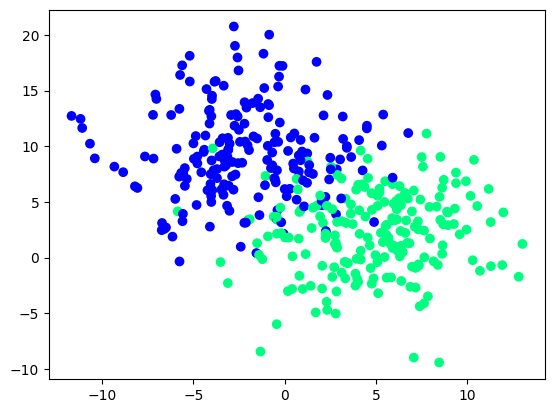

In [46]:
plt.scatter(X[:,0],X[:,1],c=y,cmap="winter")

In [50]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=30)

In [52]:
model1 = Sequential()

In [53]:
model1.add(Dense(128,activation="relu",input_dim=2))
model1.add(Dense(128,activation="relu"))
model1.add(Dense(1,activation="sigmoid"))

In [56]:
model1.compile(loss='binary_crossentropy',optimizer="adam",metrics=['accuracy'])

In [60]:
hist = model1.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=500,verbose=True)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9586 - loss: 0.1209 - val_accuracy: 0.8875 - val_loss: 0.2409
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9259 - loss: 0.1623 - val_accuracy: 0.8875 - val_loss: 0.2397
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9326 - loss: 0.1646 - val_accuracy: 0.9000 - val_loss: 0.2397
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9506 - loss: 0.1269 - val_accuracy: 0.8875 - val_loss: 0.2411
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9385 - loss: 0.1397 - val_accuracy: 0.8875 - val_loss: 0.2430
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9531 - loss: 0.1182 - val_accuracy: 0.8875 - val_loss: 0.2360
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9373 - loss: 0.1289 - val_accuracy: 0.8875 - val_loss: 0.2411
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9315 - loss: 0.1348 - val_accuracy: 0.8875 

In [58]:
from mlxtend.plotting import plot_decision_regions

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 925us/step


<Axes: >

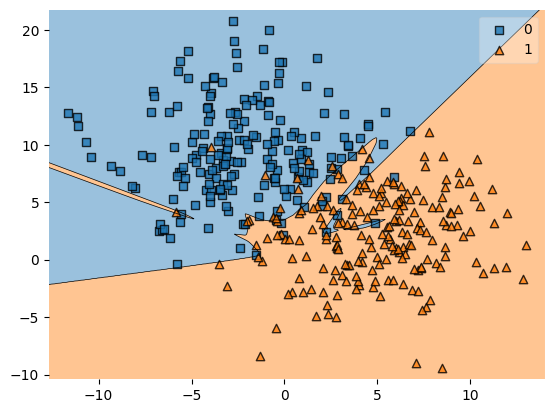

In [61]:
plot_decision_regions(X,y,model1)

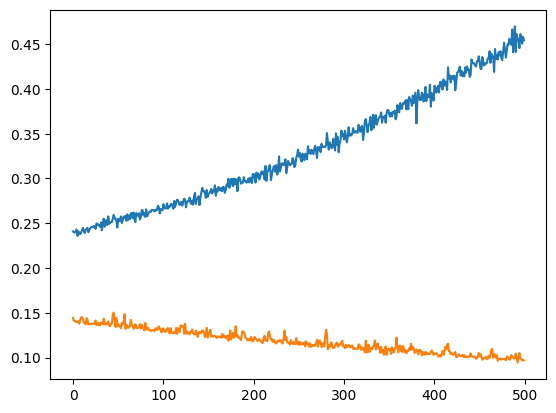

In [62]:
plt.plot(hist.history['val_loss'],label="test")
plt.plot(hist.history['loss'],label='train')

### Overfitting occurs without using the dropouts 

In [63]:
model2 = Sequential()

In [64]:
model2.add(Dense(128,activation="relu",input_dim=2))
model2.add(Dropout(0.5))
model2.add(Dense(128,activation="relu"))
model2.add(Dropout(0.5))
model2.add(Dense(1,activation="sigmoid"))

In [65]:
model2.compile(loss='binary_crossentropy',optimizer="adam",metrics=['accuracy'])
history = model2.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=500,verbose=True)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5849 - loss: 0.7620 - val_accuracy: 0.8375 - val_loss: 0.3263
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8538 - loss: 0.3422 - val_accuracy: 0.8875 - val_loss: 0.2808
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8776 - loss: 0.3198 - val_accuracy: 0.8875 - val_loss: 0.2738
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8738 - loss: 0.3041 - val_accuracy: 0.8875 - val_loss: 0.2733
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8977 - loss: 0.2470 - val_accuracy: 0.8875 - val_loss: 0.2713
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9175 - loss: 0.2321 - val_accuracy: 0.8875 - val_loss: 0.2643
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8914 - loss: 0.2927 - val_accuracy: 0.8875 - val_loss: 0.2578
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8933 - loss: 0.2501 - val_accuracy: 0.

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 879us/step


<Axes: >

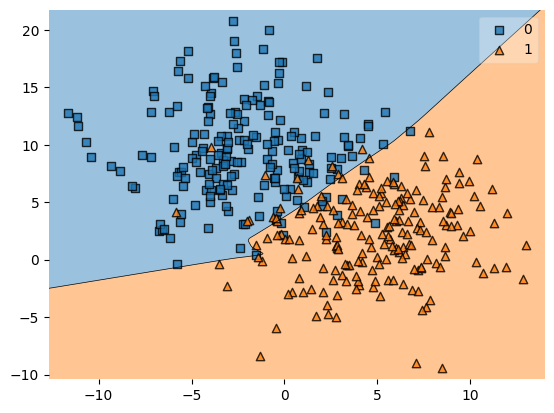

In [66]:
plot_decision_regions(X,y,model2)

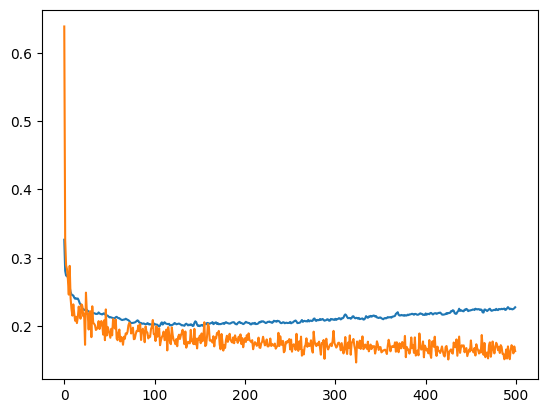

In [67]:
plt.plot(history.history['val_loss'],label="test")
plt.plot(history.history['loss'],label='train')

## With same epochs we getting best line from the graph ,so dropout is useful